⏳ Iniciando o carregamento dos dados...
✅ Dados carregados com sucesso! Shape inicial: (5000, 15)

🧹 Iniciando pipeline de limpeza de dados...
   ↳ Nenhuma linha duplicada encontrada.
   ↳ Removidas 0 linhas com valores nulos nas colunas de análise.
   ↳ Coluna 'Sustainability_Rating' padronizada (strip e uppercase).
✅ Limpeza concluída! Shape final para análise: (5000, 15)

🧠 Processando análise descritiva e gerando insights...

💡 INSIGHTS ESTRATÉGICOS AUTOMATIZADOS
• Consumo Hídrico: Marcas 'A' consomem 2.74% A MAIS água que marcas 'D' (volume abs.).
• Pegada de Carbono: Marcas 'A' emitem 1.99% A MAIS CO2 que marcas 'D' (volume abs.).

📊 Gerando painel de visualizações...


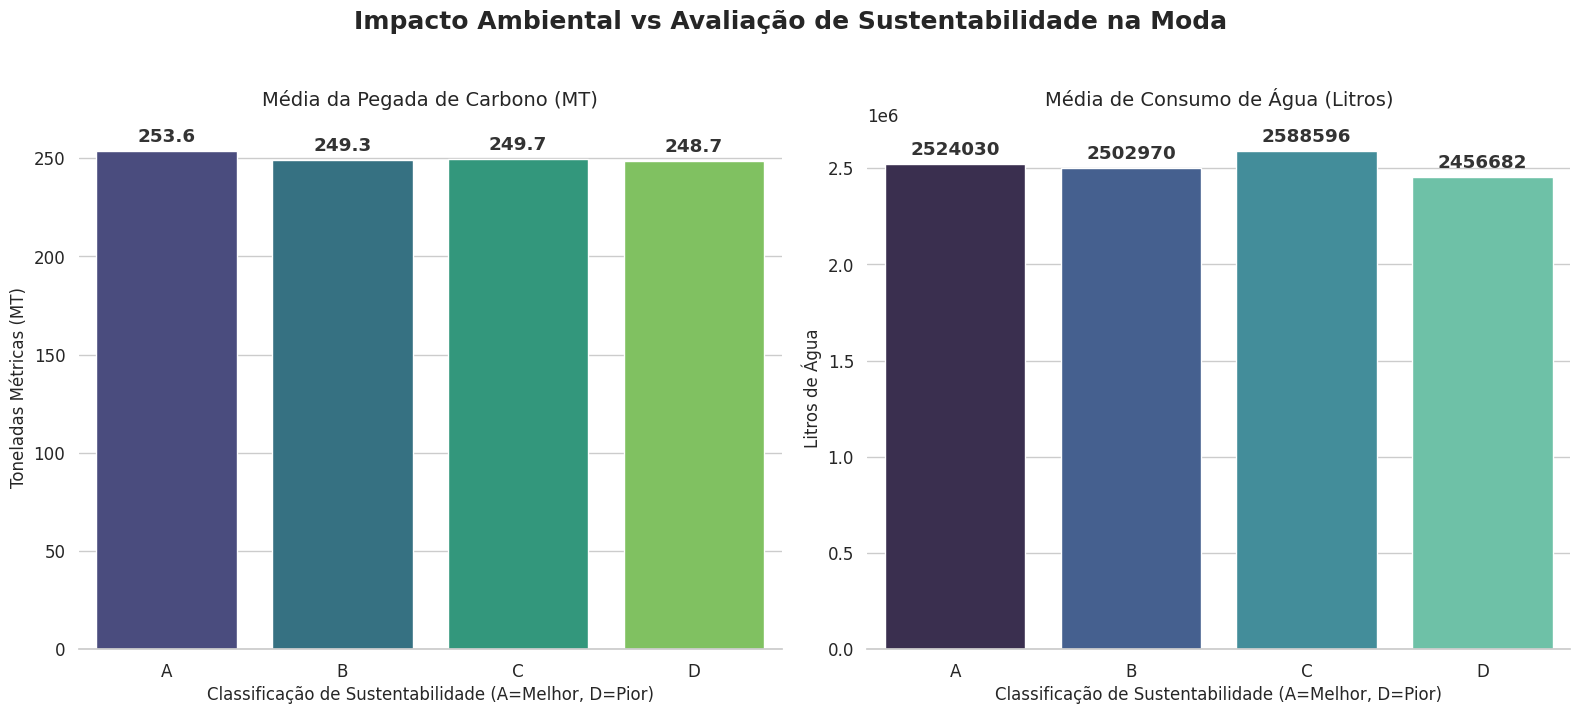

In [5]:
"""
Projeto de Análise de Dados: Sustentabilidade na Indústria da Moda
Autor: Julia de Moraes Barbosa
Descrição: Script de extração, limpeza, análise e visualização de dados
           do dataset 'Sustainable Fashion: Eco-Friendly Trends'. Foco no
           impacto ambiental (Pegada de Carbono e Consumo de Água) baseado
           no rating de sustentabilidade de marcas globais.
"""

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys

def carregar_dados(caminho_arquivo: str) -> pd.DataFrame:
    """Carrega o dataset em um DataFrame do Pandas."""
    print("⏳ Iniciando o carregamento dos dados...")
    try:
        if not os.path.exists(caminho_arquivo):
            raise FileNotFoundError(f"O arquivo '{caminho_arquivo}' não foi encontrado no diretório atual.")

        df = pd.read_csv(caminho_arquivo)
        print(f"✅ Dados carregados com sucesso! Shape inicial: {df.shape}")
        return df

    except Exception as e:
        print(f"❌ Erro crítico ao carregar os dados: {e}")
        sys.exit(1)

def limpar_dados(df: pd.DataFrame, colunas_foco: list) -> pd.DataFrame:
    """Realiza o pré-processamento e limpeza dos dados."""
    print("\n🧹 Iniciando pipeline de limpeza de dados...")

    # 1. Remoção de duplicatas
    duplicatas = df.duplicated().sum()
    if duplicatas > 0:
        df = df.drop_duplicates()
        print(f"   ↳ Removidas {duplicatas} linhas duplicadas.")
    else:
        print("   ↳ Nenhuma linha duplicada encontrada.")

    # 2. Tratamento de nulos
    shape_antes_nulos = df.shape[0]
    df = df.dropna(subset=colunas_foco).copy()
    linhas_removidas = shape_antes_nulos - df.shape[0]
    print(f"   ↳ Removidas {linhas_removidas} linhas com valores nulos nas colunas de análise.")

    # 3. Padronização Categórica
    if 'Sustainability_Rating' in df.columns:
        df['Sustainability_Rating'] = df['Sustainability_Rating'].astype(str).str.strip().str.upper()
        print("   ↳ Coluna 'Sustainability_Rating' padronizada (strip e uppercase).")

    print(f"✅ Limpeza concluída! Shape final para análise: {df.shape}")
    return df

def gerar_insights(df_limpo: pd.DataFrame) -> pd.DataFrame:
    """Calcula agregações e imprime insights automáticos no console."""
    print("\n🧠 Processando análise descritiva e gerando insights...")

    # Agrupamento das métricas
    df_agrupado = df_limpo.groupby('Sustainability_Rating')[['Carbon_Footprint_MT', 'Water_Usage_Liters']].mean().reset_index()
    df_agrupado = df_agrupado.sort_values('Sustainability_Rating')

    # Geração de Insight Automático (Comparando nota A vs D)
    nota_a = df_agrupado[df_agrupado['Sustainability_Rating'] == 'A']
    nota_d = df_agrupado[df_agrupado['Sustainability_Rating'] == 'D']

    if not nota_a.empty and not nota_d.empty:
        agua_a = nota_a['Water_Usage_Liters'].values[0]
        agua_d = nota_d['Water_Usage_Liters'].values[0]

        carbono_a = nota_a['Carbon_Footprint_MT'].values[0]
        carbono_d = nota_d['Carbon_Footprint_MT'].values[0]

        # Lógica para identificar proporção em dados absolutos
        status_agua = "MENOS" if agua_a < agua_d else "A MAIS"
        pct_agua = abs(((agua_a - agua_d) / agua_d) * 100)

        status_carbono = "MENOS" if carbono_a < carbono_d else "A MAIS"
        pct_carbono = abs(((carbono_a - carbono_d) / carbono_d) * 100)

        print("\n" + "="*60)
        print("💡 INSIGHTS ESTRATÉGICOS AUTOMATIZADOS")
        print("="*60)
        print(f"• Consumo Hídrico: Marcas 'A' consomem {pct_agua:.2f}% {status_agua} água que marcas 'D' (volume abs.).")
        print(f"• Pegada de Carbono: Marcas 'A' emitem {pct_carbono:.2f}% {status_carbono} CO2 que marcas 'D' (volume abs.).")
        print("="*60 + "\n")

    return df_agrupado

def plotar_resultados(df_agrupado: pd.DataFrame):
    """Gera as visualizações gráficas com formatação profissional."""
    print("📊 Gerando painel de visualizações...")

    sns.set_theme(style="whitegrid", font_scale=1.1)
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle('Impacto Ambiental vs Avaliação de Sustentabilidade na Moda', fontsize=18, fontweight='bold', y=1.02)

    # Gráfico 1: Pegada de Carbono
    ax1 = sns.barplot(data=df_agrupado, x='Sustainability_Rating', y='Carbon_Footprint_MT',
                      hue='Sustainability_Rating', palette='viridis', legend=False, ax=axes[0])
    axes[0].set_title('Média da Pegada de Carbono (MT)', fontsize=14, pad=15)
    axes[0].set_xlabel('Classificação de Sustentabilidade (A=Melhor, D=Pior)', fontsize=12)
    axes[0].set_ylabel('Toneladas Métricas (MT)', fontsize=12)

    for p in ax1.patches:
        ax1.annotate(format(p.get_height(), '.1f'),
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha = 'center', va = 'center', xytext = (0, 10),
                     textcoords = 'offset points', fontweight='bold', color='#333333')

    # Gráfico 2: Consumo de Água
    ax2 = sns.barplot(data=df_agrupado, x='Sustainability_Rating', y='Water_Usage_Liters',
                      hue='Sustainability_Rating', palette='mako', legend=False, ax=axes[1])
    axes[1].set_title('Média de Consumo de Água (Litros)', fontsize=14, pad=15)
    axes[1].set_xlabel('Classificação de Sustentabilidade (A=Melhor, D=Pior)', fontsize=12)
    axes[1].set_ylabel('Litros de Água', fontsize=12)

    for p in ax2.patches:
        ax2.annotate(format(p.get_height(), '.0f'),
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha = 'center', va = 'center', xytext = (0, 10),
                     textcoords = 'offset points', fontweight='bold', color='#333333')

    sns.despine(left=True, bottom=False)
    plt.tight_layout()
    plt.show()

# =====================================================================
# BLOCO DE EXECUÇÃO PRINCIPAL
# =====================================================================
if __name__ == "__main__":
    ARQUIVO_DATASET = 'sustainable_fashion_trends_2024.csv'
    COLUNAS_ESSENCIAIS = ['Carbon_Footprint_MT', 'Water_Usage_Liters', 'Sustainability_Rating']

    dados_brutos = carregar_dados(ARQUIVO_DATASET)
    dados_limpos = limpar_dados(dados_brutos, COLUNAS_ESSENCIAIS)
    analise_agrupada = gerar_insights(dados_limpos)
    plotar_resultados(analise_agrupada)